In [2]:
import numpy as np
import sympy as sp
from array import array
from utils import *

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Example 27a
### Markov Chain $(a,b,c)$

In [3]:
a = sp.symbols("a")
b = sp.symbols("b")
T1o = sp.MutableDenseNDimArray([a,b])
T2o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T3o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T1 = forget(blow(T1o),2)
T2 = blow(T2o)
T3 = forget(T3o,0)
list(general_BM_product([T1,T2,T3]))

[array([[a**3, a**2*b],
        [a*b**2, a**2*b]], dtype=object),
 array([[a*b**2, b**3],
        [a*b**2, a**2*b]], dtype=object)]

## Example 27b
### Example 27a without link $b \rightarrow c$

In [4]:
a = sp.symbols("a")
b = sp.symbols("b")
T1o = sp.MutableDenseNDimArray([a,b])
T2o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T3o = T1o
T1 = forget(blow(T1o),2)
T2 = blow(T2o)
T3 = forget(forget(T3o,0),1)
list(general_BM_product([T1,T2,T3]))

[array([[a**3, a**2*b],
        [a**2*b, a*b**2]], dtype=object),
 array([[a*b**2, b**3],
        [a**2*b, a*b**2]], dtype=object)]

## Example 28


In [5]:
a = sp.symbols("a")
b = sp.symbols("b")
T = sp.MutableDenseNDimArray([a,b])
q = 3
T_list = []
for i in range(q):
    T_list.append(T)
    print(f'Node {i}')
    back_forget_list = [j for j in range(i)]
    forw_forget_list = [j for j in range(i+2,q)]
    print(f'J = {back_forget_list}, forward_forget_list={forw_forget_list}')
    for pos in back_forget_list:
        T_list[-1] = forget(T_list[-1],pos)
    if len(T_list[-1].shape)<q:
        T_list[-1] = blow(T_list[-1])
        print('Blow applied')
    else:
        print('Blow not applied')
    for pos in forw_forget_list:
        T_list[-1] = forget(T_list[-1],pos)
general_BM_product(T_list)

Node 0
J = [], forward_forget_list=[2]
Blow applied
Node 1
J = [0], forward_forget_list=[]
Blow applied
Node 2
J = [0, 1], forward_forget_list=[]
Blow not applied


array([[[a**3, a**2*b],
        [a**2*b, a*b**2]],

       [[a**2*b, a*b**2],
        [a*b**2, b**3]]], dtype=object)

## Example 29
### Binary network with 5 nodes

In [6]:
alpha = sp.symbols("alpha")
beta = sp.symbols("beta")
edge_index = np.array([[0,1],[0,2],[1,2],[1,4],[2,3],[3,4]])
q = 5  # Total number of nodes
adjacency_matrix_5 = edge_index_to_adj(edge_index, q)

A = sp.MutableDenseNDimArray([alpha,beta])
B = sp.MutableDenseNDimArray([[alpha,beta],[beta,alpha]])
D = B
C = sp.MutableDenseNDimArray([[[alpha,beta],[beta,alpha]],[[beta,alpha],[beta,alpha]]])
E = C

# A = forget(forget(forget(blow(A),2),3),4)
# B = forget(forget(blow(B),3),4)
# C = forget(blow(C),4)
# D = blow(forget(forget(D,0),1))
# E = forget(forget(E,0),2)

t_list_5 = [A,B,C,D,E]

t_list_expanded_5 = create_network(adjacency_matrix_5,t_list_5)

from time import time
t0 = time()
bm_prod_5 = general_BM_product(t_list_expanded_5)
t_final = time()-t0
print(f'Elapsed time: {t_final} seconds')


Elapsed time: 0.009533882141113281 seconds


### Example with 7 nodes

In [7]:
alpha = sp.symbols("alpha")
beta = sp.symbols("beta")

edge_index_7 = np.array([[0,1],[0,2],[1,2],[1,4],[2,3],[3,4],[4,5],[4,6],[5,6]])
q = 7  # Total number of nodes
adjacency_matrix_7 = edge_index_to_adj(edge_index_7, q)

A = sp.MutableDenseNDimArray([alpha,beta])
B = sp.MutableDenseNDimArray([[alpha,beta],[beta,alpha]])
D = B
C = sp.MutableDenseNDimArray([[[alpha,beta],[beta,alpha]],[[beta,alpha],[beta,alpha]]])
E = C
F = B
G = C

t_list_7 = [A,B,C,D,E,F,G]

# A = forget(forget(forget(forget(forget(blow(A),2),3),4),5),6)
# B = forget(forget(forget(forget(blow(B),3),4),5),6)
# C = forget(forget(forget(blow(C),4),5),6)
# D = forget(forget(blow(forget(forget(D,0),1)),5),6)

# E = forget(blow(forget(forget(E,0),2)),6)
# F = blow(forget(forget(forget(forget(F,0),1),2),3))
# G = forget(forget(forget(forget(G,0),1),2),3)

t_list_expanded_7 = create_network(adjacency_matrix_7, t_list_7)
from time import time
t0 = time()
bm_prod_7 = general_BM_product(t_list_expanded_7)
t_final = time()-t0
print(f'Elapsed time: {t_final} seconds')


Elapsed time: 0.021183013916015625 seconds


### Example with N nodes
We can generate a random list of tensors, with appropriate dimension w.r.t the topology of the given adjacency matrix, and then generate the network for which we can compute the BM product.

In [8]:
import numpy as np

def generate_source_sink_dag(num_nodes):
    if num_nodes < 2:
        raise ValueError("Need at least 2 nodes for a source and a sink.")
        
    matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    
    # 1. Create a "backbone" to guarantee connectivity from Source to Sink
    # This ensures node 0 -> 1 -> 2 ... -> (n-1)
    for i in range(num_nodes - 1):
        matrix[i][i+1] = 1
        
    # 2. Add random forward edges to make it interesting
    # We still only populate the upper triangle (j > i) to prevent cycles
    for i in range(num_nodes):
        for j in range(i + 2, num_nodes): # i+2 to avoid overwriting the backbone
            if np.random.rand() < 0.3:
                matrix[i][j] = 1
                
    return matrix

Elapsed time for a network with 10 nodes: 0.15396404266357422 seconds
Elapsed time for a network with 11 nodes: 0.3327779769897461 seconds
Elapsed time for a network with 12 nodes: 0.7459781169891357 seconds
Elapsed time for a network with 13 nodes: 1.622628927230835 seconds
Elapsed time for a network with 14 nodes: 3.545046091079712 seconds
Elapsed time for a network with 15 nodes: 7.790901184082031 seconds
Elapsed time for a network with 16 nodes: 17.05190920829773 seconds
Elapsed time for a network with 17 nodes: 37.93160820007324 seconds
Elapsed time for a network with 18 nodes: 83.60110688209534 seconds
Elapsed time for a network with 19 nodes: 175.82947301864624 seconds


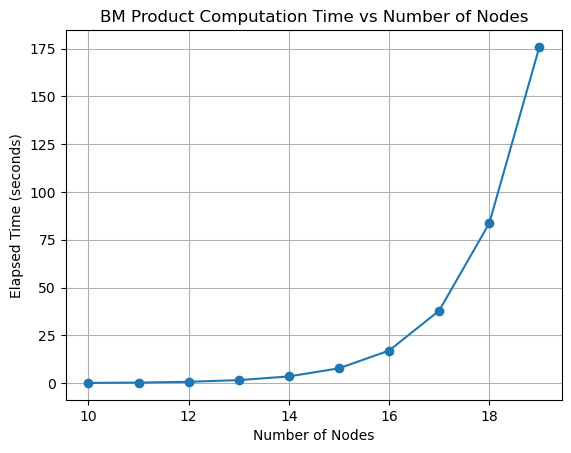

In [10]:
times = []
for nodes in range(10, 20):
    dag_matrix = generate_source_sink_dag(nodes)
    t_list_dag = create_network(dag_matrix, create_random_tensors(dag_matrix))
    from time import time
    t0 = time()
    bm_prod = BM_product(t_list_dag)
    t_final = time()-t0
    times.append(t_final)
    print(f'Elapsed time for a network with {nodes} nodes: {t_final} seconds')
    
ax, fig = plt.subplots()
fig.plot(range(10, 20), times, marker='o')
fig.set_xlabel('Number of Nodes')
fig.set_ylabel('Elapsed Time (seconds)')
fig.set_title('BM Product Computation Time vs Number of Nodes')
plt.grid()
plt.show()